# Team Project Submission #1 — Pandas DataFrame Tutorial (Step-by-step)

**Course:** CS 506 – Programming for Computing  
**Topic:** Introduction to Pandas DataFrames and Applications  
**Student/Team:** Titus Michael Masele, Amandeep Singh Saran, Anushree Raut  
**Date:** 2026-02-12

---

## What you will learn (tutorial goals)

By the end of this notebook, you will be able to:

1. Load tabular data into a **Pandas DataFrame**
2. Inspect, understand, and clean a dataset (missing values, types, duplicates)
3. Select data using **`[]`**, **`.loc`**, and **`.iloc`**
4. Filter, sort, and transform data using **vectorized operations**
5. Summarize data using **`groupby()`**, pivot tables, and aggregations
6. Combine data using **`merge()`** (joins)
7. Visualize data using built-in Pandas plotting (Matplotlib backend)
8. Export results to **CSV** for reporting/sharing
9. Understand how Pandas relates to **NumPy**

> ✅ This notebook is written with original interpretation and explains *why* each step is used.


## 0) Setup & Environment

We will use:
- `pandas` for DataFrames
- `numpy` for fast numerical operations
- `matplotlib` for plotting (Pandas uses Matplotlib under the hood)

Run the next cell to import libraries and confirm versions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("pandas:", pd.__version__)
print("numpy:", np.__version__)


pandas: 3.0.0
numpy: 2.4.2


## 1) Get a dataset (two options)

### Option A (recommended): Use a real CSV you already have
Place a CSV file in the same folder as this notebook (example: `weather.csv` or `sales.csv`).

### Option B (works anywhere): Auto-generate a realistic dataset
If you do not have a dataset yet, this notebook can generate one called `weather_sample.csv`.

**Why this matters:**  
A real dataset demonstrates practical skills, but generating a dataset lets the notebook run reliably even when the CSV is missing.


In [2]:
from pathlib import Path

DATA_FILE = Path("weather_sample.csv")  # change this to your real CSV if you have one

def generate_weather_sample_csv(path: Path, n_rows: int = 365) -> None:
    """Create a realistic weather dataset for practice."""
    rng = np.random.default_rng(42)
    dates = pd.date_range("2024-01-01", periods=n_rows, freq="D")

    # Simulated temperatures (°C) with seasonal pattern + noise
    day_of_year = np.arange(n_rows)
    seasonal = 10 + 10 * np.sin(2 * np.pi * day_of_year / 365)
    temp_c = seasonal + rng.normal(0, 2.5, size=n_rows)

    # Humidity (%)
    humidity = np.clip(60 + rng.normal(0, 12, size=n_rows), 15, 100)

    # Wind speed (km/h)
    wind_kmh = np.clip(rng.normal(15, 6, size=n_rows), 0, None)

    # City categories for grouping
    cities = rng.choice(["Seattle", "San Jose", "Dar es Salaam"], size=n_rows, p=[0.45, 0.35, 0.20])

    # Introduce missing values intentionally (real-world messiness)
    temp_c[rng.choice(n_rows, size=10, replace=False)] = np.nan
    humidity[rng.choice(n_rows, size=8, replace=False)] = np.nan

    df = pd.DataFrame({
        "date": dates,
        "city": cities,
        "temp_c": np.round(temp_c, 1),
        "humidity_pct": np.round(humidity, 0),
        "wind_kmh": np.round(wind_kmh, 1),
    })

    # Duplicate a couple rows intentionally
    df = pd.concat([df, df.iloc[[5, 10]]], ignore_index=True)
    df.to_csv(path, index=False)

if not DATA_FILE.exists():
    generate_weather_sample_csv(DATA_FILE)
    print(f"Generated sample dataset: {DATA_FILE.resolve()}")
else:
    print(f"Using existing dataset: {DATA_FILE.resolve()}")


Using existing dataset: /home/geekbrain/Desktop/Programming/Team_Project/weather_sample.csv


## 2) Load the dataset into a DataFrame

We use `pd.read_csv()` to create a DataFrame.

**Tip:** When loading a dataset, always check:
- column names
- data types
- missing values


In [3]:
import pandas as pd
df = pd.read_csv(DATA_FILE)
df.head()


,date,city,temp_c,humidity_pct,wind_kmh
0,2024-01-01,Dar es Salaam,10.8,78.0,17.7
1,2024-01-02,San Jose,7.6,51.0,15.3
2,2024-01-03,Seattle,12.2,50.0,18.3
3,2024-01-04,San Jose,12.9,62.0,13.9
4,2024-01-05,Dar es Salaam,5.8,70.0,16.7


## 3) First inspection (the 5 fastest checks)

These are fast checks on any dataset:
- `shape`: how many rows/columns?
- `columns`: what are the fields?
- `info()`: types + missing values
- `describe()`: quick stats for numeric columns
- `isna().sum()`: missing value counts


In [4]:
print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.info()


Shape: (367, 5)
Columns: ['date', 'city', 'temp_c', 'humidity_pct', 'wind_kmh']
<class 'pandas.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          367 non-null    str    
 1   city          367 non-null    str    
 2   temp_c        357 non-null    float64
 3   humidity_pct  359 non-null    float64
 4   wind_kmh      367 non-null    float64
dtypes: float64(3), str(2)
memory usage: 14.5 KB


In [5]:
df.describe()

,temp_c,humidity_pct,wind_kmh
count,357.000000,359.000000,367.00000
mean,9.963025,58.969359,15.13297
std,7.320974,12.282824,5.77772
min,-5.900000,24.000000,0.00000
25%,3.300000,50.000000,11.65000
50%,10.500000,59.000000,15.30000
75%,16.700000,67.000000,18.70000
max,24.100000,91.000000,34.10000


In [6]:
df.isna().sum()


date             0
city             0
temp_c          10
humidity_pct     8
wind_kmh         0
dtype: int64

## 4) Clean up: fix types, remove duplicates, handle missing values

### 4.1 Convert `date` to datetime  
### 4.2 Remove duplicates  
### 4.3 Handle missing values  

**Why we do this:**  
Cleaning is required before analysis; missing values and duplicates can change averages, counts, and charts.


In [7]:
# 4.1 Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# 4.2 Remove duplicates
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Removed duplicates: {before - after}")

df.head()


Removed duplicates: 2


,date,city,temp_c,humidity_pct,wind_kmh
0,2024-01-01,Dar es Salaam,10.8,78.0,17.7
1,2024-01-02,San Jose,7.6,51.0,15.3
2,2024-01-03,Seattle,12.2,50.0,18.3
3,2024-01-04,San Jose,12.9,62.0,13.9
4,2024-01-05,Dar es Salaam,5.8,70.0,16.7


In [8]:
# 4.3 Missing values strategy:
# - temp_c: fill with city-level median (more realistic than global mean)
# - humidity_pct: fill with overall median

df["temp_c"] = df.groupby("city")["temp_c"].transform(lambda s: s.fillna(s.median()))
df["humidity_pct"] = df["humidity_pct"].fillna(df["humidity_pct"].median())

df.isna().sum()


date            0
city            0
temp_c          0
humidity_pct    0
wind_kmh        0
dtype: int64

## 5) Create new columns (feature engineering)

We add:
- `temp_f` (C → F)
- `month` and `weekday` from the date
- `is_windy` (simple rule-based feature)

**Why we do this:**  
New columns turn raw data into features we can summarize and visualize.


In [9]:
df["temp_f"] = df["temp_c"] * 9/5 + 32
df["month"] = df["date"].dt.month
df["weekday"] = df["date"].dt.day_name()
df["is_windy"] = df["wind_kmh"] >= 25

df.head()


,date,city,temp_c,humidity_pct,wind_kmh,temp_f,month,weekday,is_windy
0,2024-01-01,Dar es Salaam,10.8,78.0,17.7,51.44,1,Monday,False
1,2024-01-02,San Jose,7.6,51.0,15.3,45.68,1,Tuesday,False
2,2024-01-03,Seattle,12.2,50.0,18.3,53.96,1,Wednesday,False
3,2024-01-04,San Jose,12.9,62.0,13.9,55.22,1,Thursday,False
4,2024-01-05,Dar es Salaam,5.8,70.0,16.7,42.44,1,Friday,False


## 6) Selecting data (columns, rows, and slices)

- `df["col"]` → Series  
- `df[["a","b"]]` → DataFrame  
- `df[0:5]` → row slice  

For precise work, prefer `.loc` and `.iloc`.


In [10]:
df["city"].head()


0    Dar es Salaam
1         San Jose
2          Seattle
3         San Jose
4    Dar es Salaam
Name: city, dtype: str

In [11]:
df[["date", "city", "temp_c"]].head()


,date,city,temp_c
0,2024-01-01,Dar es Salaam,10.8
1,2024-01-02,San Jose,7.6
2,2024-01-03,Seattle,12.2
3,2024-01-04,San Jose,12.9
4,2024-01-05,Dar es Salaam,5.8


In [12]:
df[0:5]


,date,city,temp_c,humidity_pct,wind_kmh,temp_f,month,weekday,is_windy
0,2024-01-01,Dar es Salaam,10.8,78.0,17.7,51.44,1,Monday,False
1,2024-01-02,San Jose,7.6,51.0,15.3,45.68,1,Tuesday,False
2,2024-01-03,Seattle,12.2,50.0,18.3,53.96,1,Wednesday,False
3,2024-01-04,San Jose,12.9,62.0,13.9,55.22,1,Thursday,False
4,2024-01-05,Dar es Salaam,5.8,70.0,16.7,42.44,1,Friday,False


## 7) `.loc` vs `.iloc` (key indexing concept)

- `.loc` = label-based selection  
- `.iloc` = position-based selection  

We set the date as index to demonstrate `.loc` with time ranges.


In [13]:
df2 = df.set_index("date").sort_index()
df2.head()


,city,temp_c,humidity_pct,wind_kmh,temp_f,month,weekday,is_windy
date,,,,,,,,
2024-01-01,Dar es Salaam,10.8,78.0,17.7,51.44,1,Monday,False
2024-01-02,San Jose,7.6,51.0,15.3,45.68,1,Tuesday,False
2024-01-03,Seattle,12.2,50.0,18.3,53.96,1,Wednesday,False
2024-01-04,San Jose,12.9,62.0,13.9,55.22,1,Thursday,False
2024-01-05,Dar es Salaam,5.8,70.0,16.7,42.44,1,Friday,False


In [14]:
df2.loc["2024-03-01":"2024-03-07", ["city", "temp_c", "humidity_pct"]]


,city,temp_c,humidity_pct
date,,,
2024-03-01,Seattle,14.4,56.0
2024-03-02,Seattle,17.8,70.0
2024-03-03,Dar es Salaam,19.2,81.0
2024-03-04,Dar es Salaam,20.3,43.0
2024-03-05,Dar es Salaam,20.7,65.0
2024-03-06,Seattle,21.0,48.0
2024-03-07,Seattle,18.2,66.0


In [15]:
df2.iloc[0:5, 0:3]


,city,temp_c,humidity_pct
date,,,
2024-01-01,Dar es Salaam,10.8,78.0
2024-01-02,San Jose,7.6,51.0
2024-01-03,Seattle,12.2,50.0
2024-01-04,San Jose,12.9,62.0
2024-01-05,Dar es Salaam,5.8,70.0


## 8) Filtering rows with boolean masks

Examples:
- All windy days
- Seattle days where temperature ≥ 15°C

Use `&` for AND and wrap conditions in parentheses.


In [16]:
df[df["is_windy"]].head()


,date,city,temp_c,humidity_pct,wind_kmh,temp_f,month,weekday,is_windy
16,2024-01-17,San Jose,13.6,59.0,25.8,56.48,1,Wednesday,True
23,2024-01-24,Seattle,13.5,63.0,27.3,56.30,1,Wednesday,True
24,2024-01-25,San Jose,12.9,43.0,25.7,55.22,1,Thursday,True
39,2024-02-09,Seattle,17.8,66.0,25.1,64.04,2,Friday,True
40,2024-02-10,Seattle,18.2,57.0,25.4,64.76,2,Saturday,True


In [17]:
df[(df["city"] == "Seattle") & (df["temp_c"] >= 15)].head()


,date,city,temp_c,humidity_pct,wind_kmh,temp_f,month,weekday,is_windy
22,2024-01-23,Seattle,16.8,66.0,8.9,62.24,1,Tuesday,False
26,2024-01-27,Seattle,15.7,61.0,9.5,60.26,1,Saturday,False
27,2024-01-28,Seattle,15.4,54.0,20.1,59.72,1,Sunday,False
28,2024-01-29,Seattle,15.7,66.0,18.8,60.26,1,Monday,False
30,2024-01-31,Seattle,20.3,62.0,22.5,68.54,1,Wednesday,False


## 9) Sorting and top results

Sorting helps find extremes (highest temperature days).


In [18]:
df.sort_values("temp_c", ascending=False).head(10)


,date,city,temp_c,humidity_pct,wind_kmh,temp_f,month,weekday,is_windy
139,2024-05-19,San Jose,24.1,24.0,14.7,75.38,5,Sunday,False
101,2024-04-11,San Jose,23.1,56.0,24.4,73.58,4,Thursday,False
118,2024-04-28,Dar es Salaam,23.0,67.0,10.8,73.40,4,Sunday,False
57,2024-02-27,Dar es Salaam,22.0,53.0,13.8,71.60,2,Tuesday,False
123,2024-05-03,San Jose,21.9,50.0,15.2,71.42,5,Friday,False
138,2024-05-18,San Jose,21.9,42.0,11.5,71.42,5,Saturday,False
90,2024-03-31,Seattle,21.7,62.0,12.1,71.06,3,Sunday,False
108,2024-04-18,Seattle,21.7,62.0,26.0,71.06,4,Thursday,True
103,2024-04-13,San Jose,21.6,73.0,12.7,70.88,4,Saturday,False
68,2024-03-09,Seattle,21.4,38.0,21.2,70.52,3,Saturday,False


## 10) GroupBy: summarize by city and month

GroupBy answers business/data questions quickly:
- average temperature by city
- average humidity by city
- windy-day percentage by city


In [19]:
city_summary = df.groupby("city").agg(
    avg_temp_c=("temp_c", "mean"),
    avg_humidity=("humidity_pct", "mean"),
    avg_wind=("wind_kmh", "mean"),
    days=("city", "size")
).sort_values("avg_temp_c", ascending=False)

city_summary


,avg_temp_c,avg_humidity,avg_wind,days
city,,,,
San Jose,10.396491,58.719298,14.920175,114
Seattle,10.116864,59.745562,14.972189,169
Dar es Salaam,9.090244,57.353659,15.679268,82


In [20]:
windy_rate = df.groupby("city")["is_windy"].mean().sort_values(ascending=False)
windy_rate


city
Dar es Salaam    0.060976
Seattle          0.041420
San Jose         0.035088
Name: is_windy, dtype: float64

## 11) Pivot tables (reporting-style summaries)

We create a city × month table of average temperature.


In [21]:
pivot = df.pivot_table(
    index="city",
    columns="month",
    values="temp_c",
    aggfunc="mean"
)
pivot


month,1,2,3,4,5,6,7,8,9,10,11,12
city,,,,,,,,,,,,
Dar es Salaam,11.314286,16.750000,19.120000,19.683333,17.13750,12.616667,5.685714,3.6400,1.170000,0.755556,3.537500,6.880000
San Jose,12.522222,17.355556,18.612500,19.733333,17.70625,11.963636,8.523077,3.8650,2.316667,-0.055556,5.056250,7.538462
Seattle,13.533333,16.928571,19.407143,17.908333,15.92000,12.576923,7.490909,1.9875,0.200000,1.250000,3.414286,7.695833


## 12) Reshaping with `melt()` (wide → long)

Long format is often preferred for visualization and ML pipelines.


In [22]:
pivot_reset = pivot.reset_index()
melted = pivot_reset.melt(id_vars="city", var_name="month", value_name="avg_temp_c")
melted.head()


,city,month,avg_temp_c
0,Dar es Salaam,1,11.314286
1,San Jose,1,12.522222
2,Seattle,1,13.533333
3,Dar es Salaam,2,16.750000
4,San Jose,2,17.355556


## 13) Merging (joins) — combine DataFrames like SQL

We merge a small lookup table (city → region).


In [23]:
city_lookup = pd.DataFrame({
    "city": ["Seattle", "San Jose", "Dar es Salaam"],
    "region": ["USA - Pacific NW", "USA - Bay Area", "Tanzania"]
})

df_merged = df.merge(city_lookup, on="city", how="left")
df_merged.head()


,date,city,temp_c,humidity_pct,wind_kmh,temp_f,month,weekday,is_windy,region
0,2024-01-01,Dar es Salaam,10.8,78.0,17.7,51.44,1,Monday,False,Tanzania
1,2024-01-02,San Jose,7.6,51.0,15.3,45.68,1,Tuesday,False,USA - Bay Area
2,2024-01-03,Seattle,12.2,50.0,18.3,53.96,1,Wednesday,False,USA - Pacific NW
3,2024-01-04,San Jose,12.9,62.0,13.9,55.22,1,Thursday,False,USA - Bay Area
4,2024-01-05,Dar es Salaam,5.8,70.0,16.7,42.44,1,Friday,False,Tanzania


## 14) Visualization (Pandas uses Matplotlib)

We will create:
1. Histogram: temperature distribution  
2. Bar chart: average temperature per city  
3. Line plot: temperature trend over time for one city  
4. Scatter plot: wind speed vs temperature  


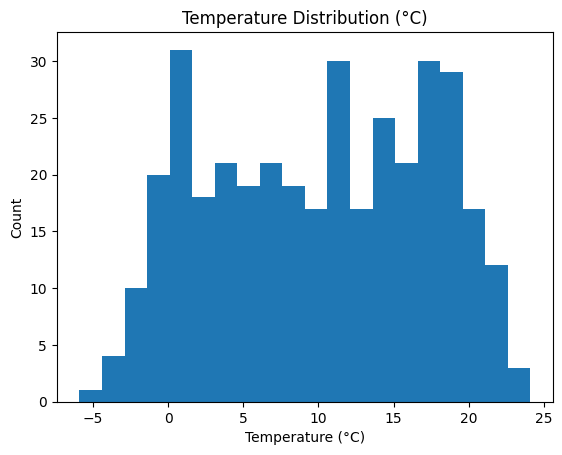

In [24]:
df["temp_c"].plot(kind="hist", bins=20)
plt.title("Temperature Distribution (°C)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Count")
plt.show()


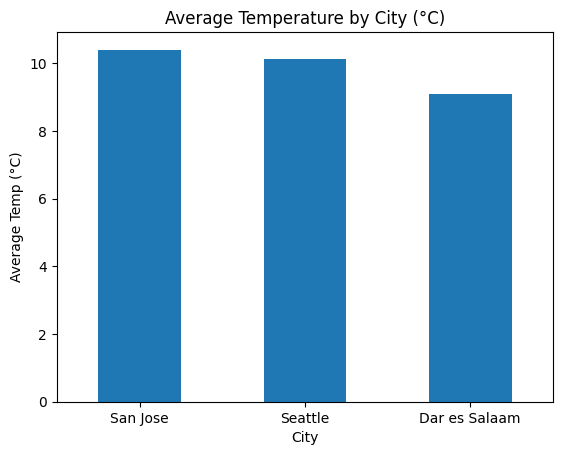

In [25]:
city_summary["avg_temp_c"].plot(kind="bar")
plt.title("Average Temperature by City (°C)")
plt.xlabel("City")
plt.ylabel("Average Temp (°C)")
plt.xticks(rotation=0)
plt.show()


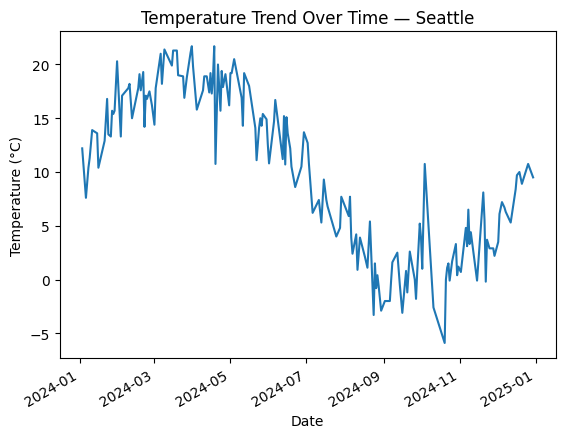

In [26]:
city_choice = "Seattle"
city_ts = df2[df2["city"] == city_choice]["temp_c"]

city_ts.plot()
plt.title(f"Temperature Trend Over Time — {city_choice}")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.show()


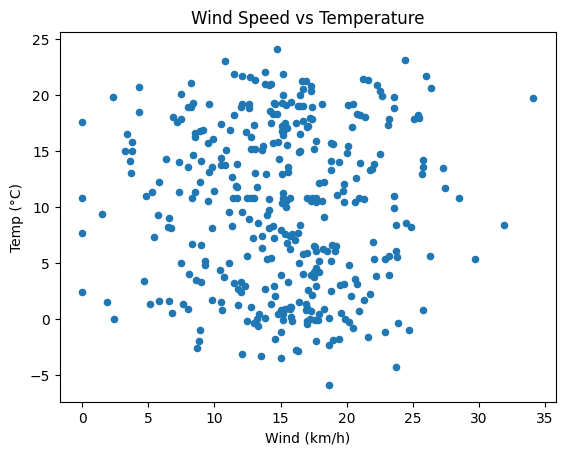

In [27]:
df.plot(kind="scatter", x="wind_kmh", y="temp_c")
plt.title("Wind Speed vs Temperature")
plt.xlabel("Wind (km/h)")
plt.ylabel("Temp (°C)")
plt.show()


## 15) Relationship to NumPy (under the hood)

Pandas columns are often backed by NumPy arrays.
We can convert between them and perform fast numerical operations.


In [28]:
arr = df[["temp_c", "humidity_pct", "wind_kmh"]].to_numpy()
print("NumPy array shape:", arr.shape)
arr[:5]


NumPy array shape: (365, 3)


array([[10.8, 78. , 17.7],
       [ 7.6, 51. , 15.3],
       [12.2, 50. , 18.3],
       [12.9, 62. , 13.9],
       [ 5.8, 70. , 16.7]])

In [29]:
temp = df["temp_c"].to_numpy()
temp_z = (temp - temp.mean()) / temp.std()
temp_z[:5]


array([ 0.11434273, -0.32839658,  0.30804118,  0.4048904 , -0.57743744])

## 16) Export results (for reports or sharing)

We export:
- cleaned dataset
- summary table


In [30]:
from pathlib import Path

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

df.to_csv(OUTPUT_DIR / "cleaned_weather.csv", index=False)
city_summary.to_csv(OUTPUT_DIR / "city_summary.csv")

print("Saved:")
print("-", (OUTPUT_DIR / "cleaned_weather.csv").resolve())
print("-", (OUTPUT_DIR / "city_summary.csv").resolve())


Saved:
- /home/geekbrain/Desktop/Programming/Team_Project/outputs/cleaned_weather.csv
- /home/geekbrain/Desktop/Programming/Team_Project/outputs/city_summary.csv


## 17) Final summary (what we demonstrated)

✅ Loaded data into a DataFrame  
✅ Inspected structure, types, and missing values  
✅ Cleaned duplicates + filled missing values with a realistic strategy  
✅ Created new columns (feature engineering)  
✅ Selected data using `[]`, `.loc`, and `.iloc`  
✅ Filtered, sorted, and summarized the dataset  
✅ Used `groupby()`, pivot tables, and reshaping  
✅ Merged a lookup table (join)  
✅ Visualized patterns using Pandas plotting  
✅ Exported cleaned data and summary outputs  
✅ Explained how Pandas relates to NumPy  

### Next steps (if expanding for AI/ML)
- Use this cleaned dataset as input to a model (scikit-learn)
- Build time-based features (rolling averages, lag features)
- Evaluate prediction performance
